# Drawing on Images

## Objectives: 

- Projecting Bounding Boxes / Trajectories
- Inserting text to images (e.g., labels, scores)   

> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

In [1]:
# Our Setup, Import Libaries, Create our Imshow Function and Download our Images
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

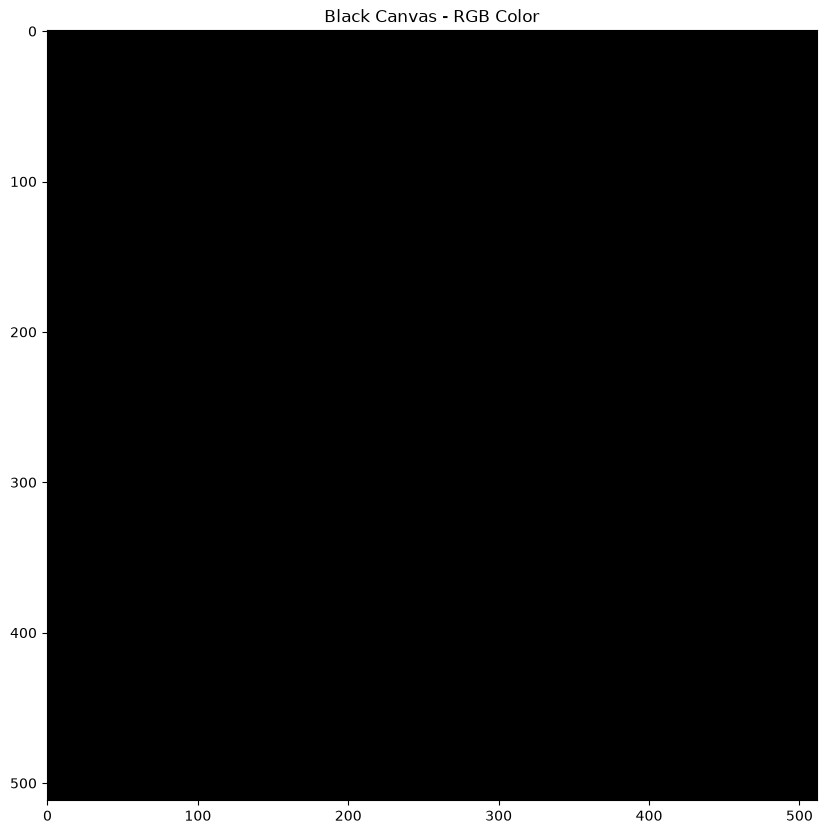

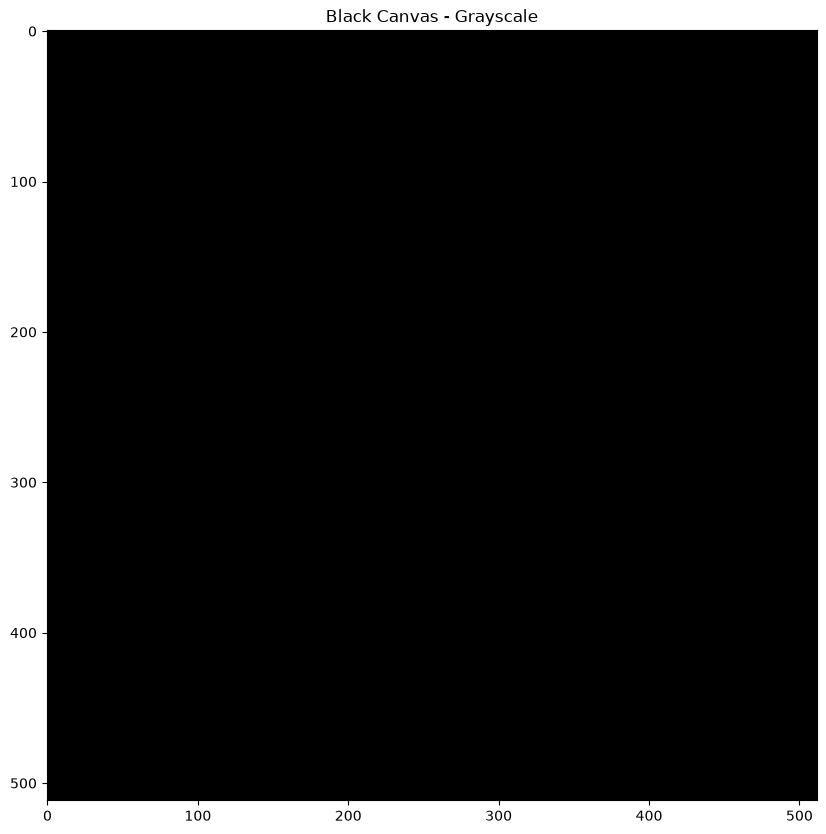

In [2]:
# Create a black image using numpy to create and array of black 
image = np.zeros((512,512,3), np.uint8)

# Can we make this in black and white? grayscale
image_gray = np.zeros((512,512), np.uint8)

# Black would be the same as a greyscale or color image (same for white)
imshow("Black Canvas - RGB Color", image)
imshow("Black Canvas - Grayscale", image_gray)

# **cv2.line Syntax**

## cv2.line(image, starting cordinates, ending cordinates, color, thickness)

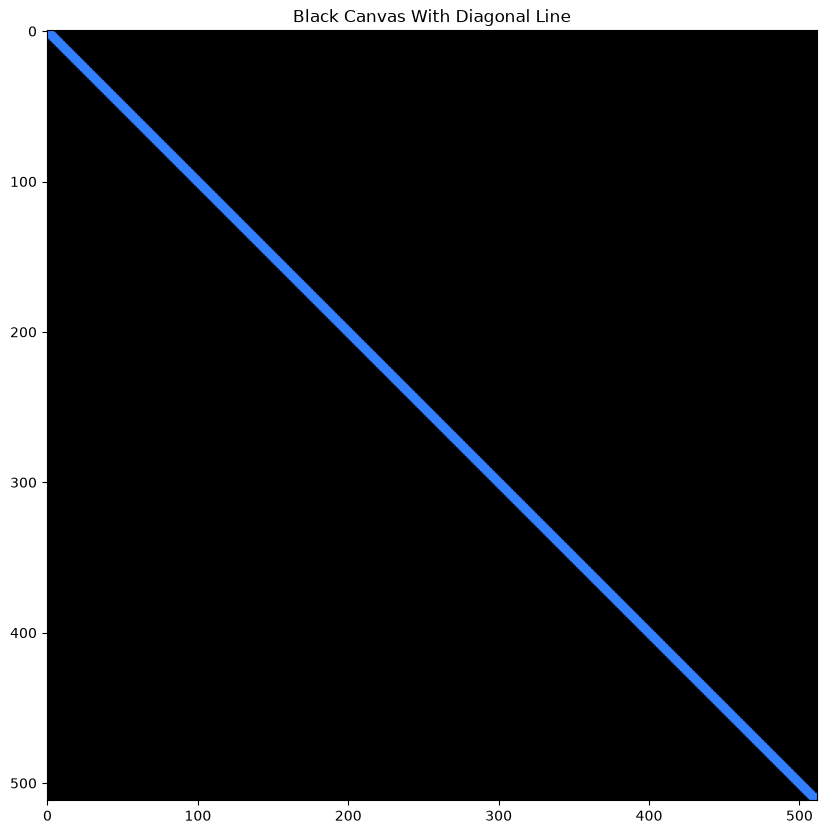

In [3]:
# Note this is an inplace operation, meaning it changes the input image
# Unlike many other OpenCV functions that return a new image leaving the input unaffected

cv2.line(image, (0,0), (511,511), (255,127,50), 5)

imshow("Black Canvas With Diagonal Line", image)

### **Drawing Rectangles (Bounding Boxes)**

```cv2.rectangle(image, starting vertex, opposite vertex, color, thickness)```

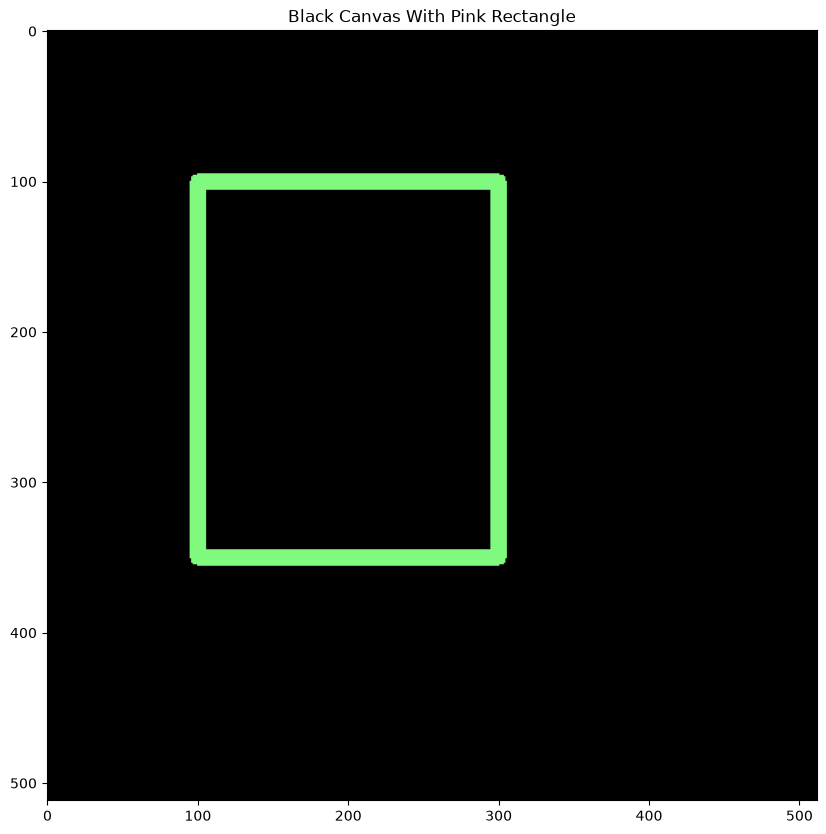

In [4]:
# Create our black canvas again because now it has a line in it
image = np.zeros((512,512,3), np.uint8)

# Thickness - if positive. Negative thickness means that it is filled
cv2.rectangle(image, (100,100), (300,350), (127,250,127), 10)
imshow("Black Canvas With Pink Rectangle", image)

### **Circles**

```cv2.cirlce(image, center, radius, color, fill)```

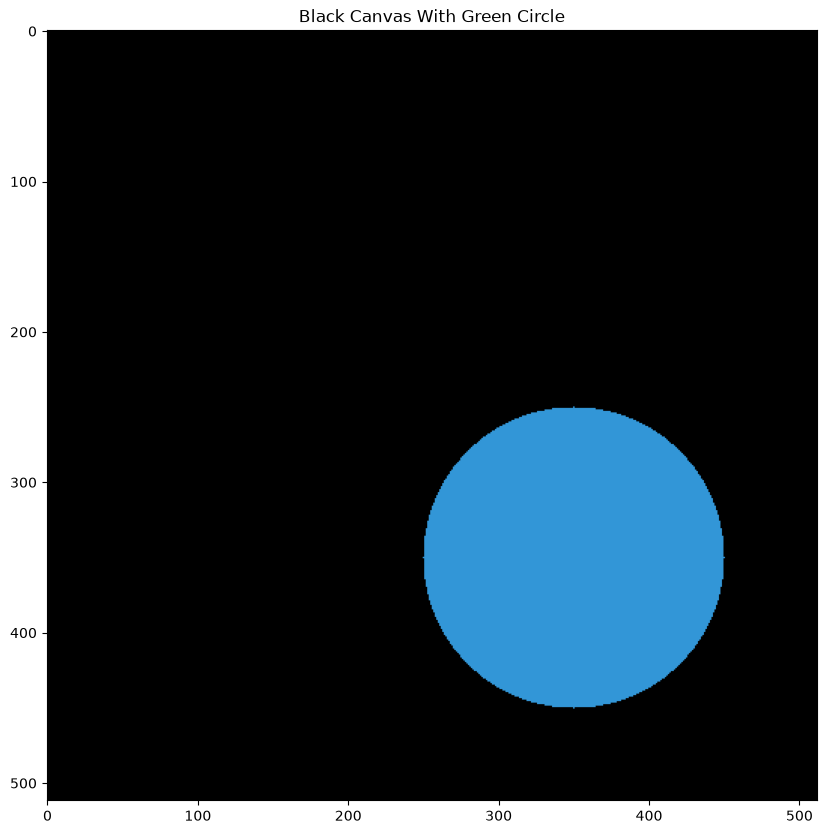

In [5]:
image = np.zeros((512,512,3), np.uint8)

cv2.circle(image, (350, 350), 100, (215,150,50), -1)  # -1 indicates  filled circle
imshow("Black Canvas With Green Circle", image)

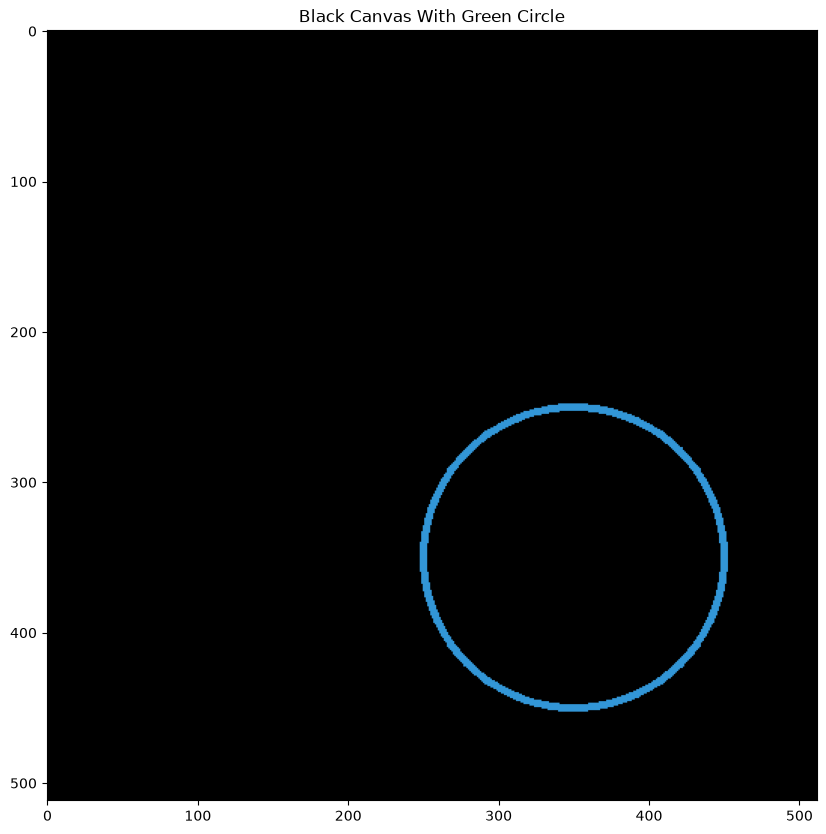

In [6]:
image = np.zeros((512,512,3), np.uint8)

cv2.circle(image, (350, 350), 100, (215,150,50), 4) # Thickness value greater than zero gives us a circle line
imshow("Black Canvas With Green Circle", image)

### **Polygons**

```cv2.polylines(image, points, Closed, color, thickness)```

if Closed = True, we join the first and last points.

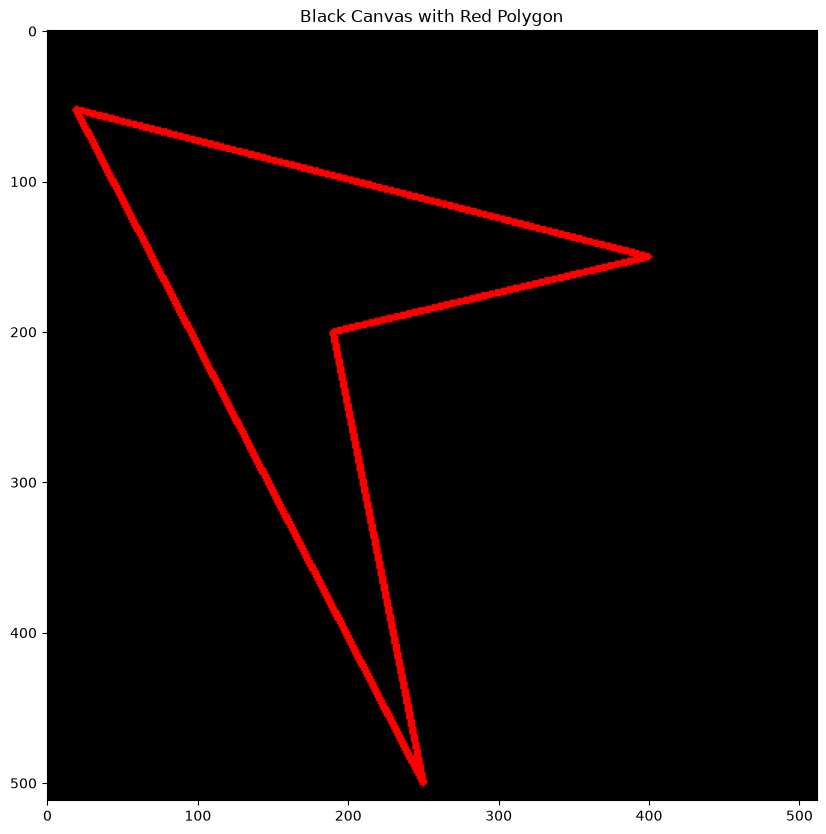

In [7]:
image = np.zeros((512,512,3), np.uint8)

# Let's define four points
pts = np.array( [[19,52], [400,150], [190,200], [250,500]], np.int32)

# Let's now reshape our points in form  required by polylines
pts = pts.reshape((-1,1,2))

cv2.polylines(image, [pts], True, (0,0,255), 3)
imshow("Black Canvas with Red Polygon", image)

In [8]:
# cv2.polylines requires our data be shaped in this way:
pts = np.array( [[10,50], [400,50], [90,200], [50,500]], np.int32)
pts.shape

(4, 2)

In [9]:
pts = pts.reshape((-1,1,2))
pts.shape

(4, 1, 2)

### **Adding Text with cv2.putText**

```cv2.putText(image, 'Text to Display', bottom left starting point, Font, Font Size, Color, Thickness)```

**Available Fonts**
- FONT_HERSHEY_SIMPLEX, FONT_HERSHEY_PLAIN
- FONT_HERSHEY_DUPLEX,FONT_HERSHEY_COMPLEX 
- FONT_HERSHEY_TRIPLEX, FONT_HERSHEY_COMPLEX_SMALL
- FONT_HERSHEY_SCRIPT_SIMPLEX
- FONT_HERSHEY_SCRIPT_COMPLEX

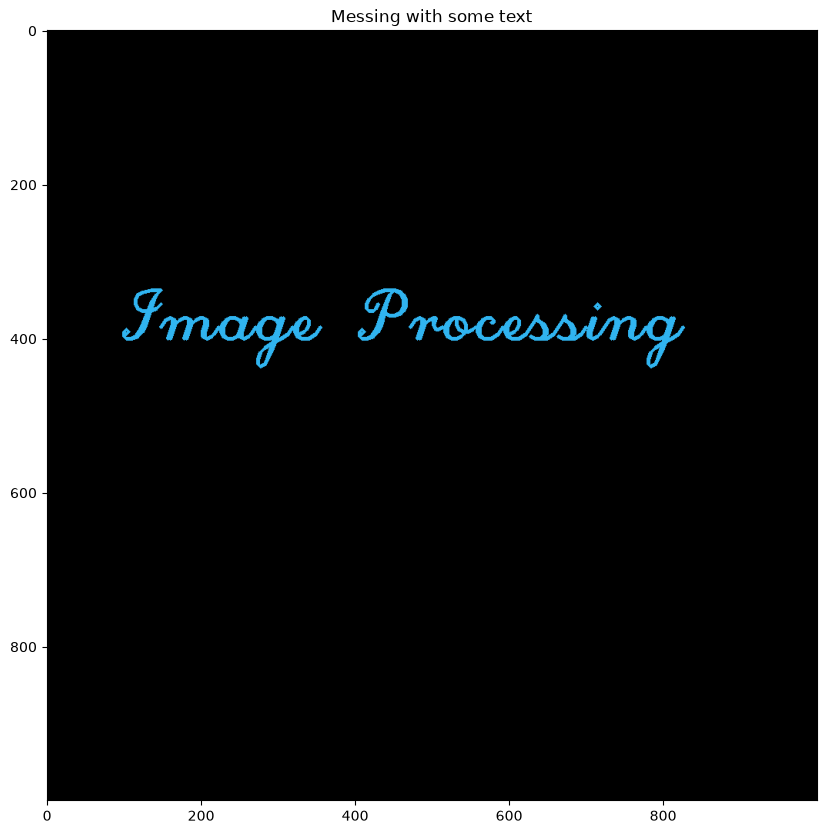

In [10]:
image = np.zeros((1000,1000,3), np.uint8)
ourString =  'Image Processing'
cv2.putText(image, ourString, (100,400), cv2.FONT_HERSHEY_SCRIPT_COMPLEX, 3, (240,180,48), 4)
imshow("Messing with some text", image)

### If you want to push this further

- Draw a bounding box *with a label*: a filled rectangle behind the text (like a detector's output) using `cv2.rectangle(..., -1)` followed by `cv2.putText`.
- Animate a shape — draw a circle at increasing radius across a loop of frames and pass the frames to `nb_utils.save_gif` to see your first generated GIF.